In [1]:
from cat_classifier import NeuralNetwork, train_cat_classifier

✅ Loaded data directly from GitHub!
Training set shape: (209, 64, 64, 3)
Training labels shape: (1, 209)
Test set shape: (50, 64, 64, 3)
Test labels shape: (1, 50)
Classes: [b'non-cat' b'cat']


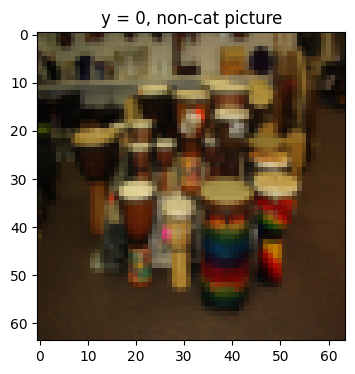

train_x's shape: (12288, 209)
test_x's shape: (12288, 50)
Training Neural Network for Cat vs Non-Cat Classification

Training neural network...
Epoch 0 loss: 0.9446
Epoch 100 loss: 0.3786
Epoch 200 loss: 0.3129
Epoch 300 loss: 0.3913
Epoch 400 loss: 0.4004
Epoch 500 loss: 0.3216
Epoch 600 loss: 0.3485
Epoch 700 loss: 0.3819
Epoch 800 loss: 0.3256
Epoch 900 loss: 0.3677
Epoch 1000 loss: 0.3167
Epoch 1100 loss: 0.4273
Epoch 1200 loss: 0.2648
Epoch 1300 loss: 0.3710
Epoch 1400 loss: 0.5829
Epoch 1500 loss: 0.4795
Epoch 1600 loss: 0.2954
Epoch 1700 loss: 0.3638
Epoch 1800 loss: 0.3783
Epoch 1900 loss: 0.3314
Loss graph saved to plots/loss_curve_batch_32.png


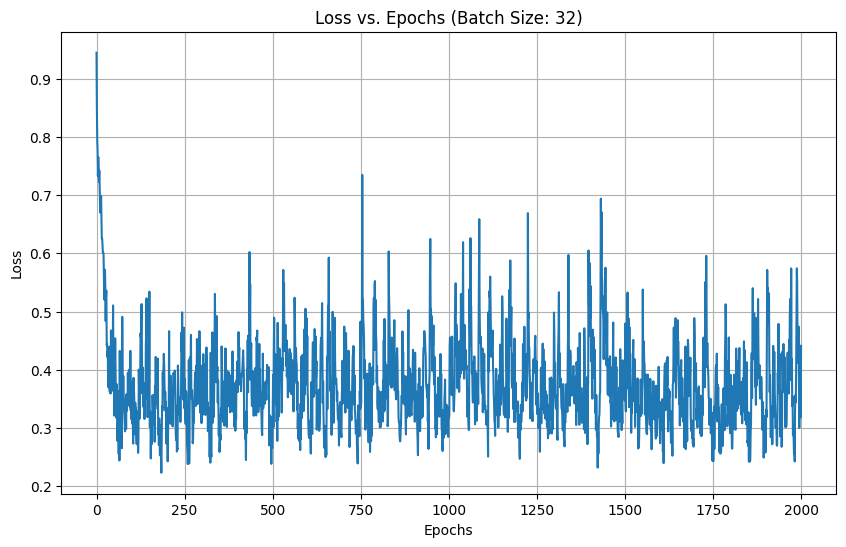


Training accuracy: 95.22%
Test accuracy: 78.00%

Viewing some predictions:


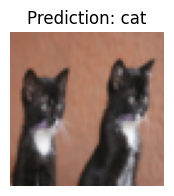

True label: cat
------------------------------


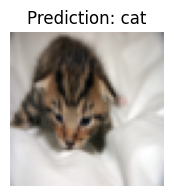

True label: cat
------------------------------


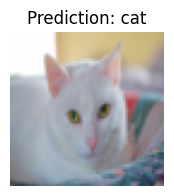

True label: cat
------------------------------


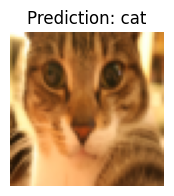

True label: cat
------------------------------


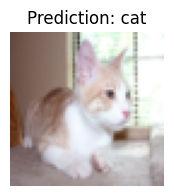

True label: cat
------------------------------


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import requests
import io

# Function to load data directly from GitHub URLs
def load_data():
    # GitHub file URLs
    train_url = 'https://github.com/DaJunn/Andrew-NG/raw/DeepLearning.AI/train_catvnoncat.h5'
    test_url = 'https://github.com/DaJunn/Andrew-NG/raw/DeepLearning.AI/test_catvnoncat.h5'

    # Download the train file
    train_response = requests.get(train_url)
    train_bytes = io.BytesIO(train_response.content)

    # Download the test file
    test_response = requests.get(test_url)
    test_bytes = io.BytesIO(test_response.content)

    # Open the HDF5 files from memory
    train_dataset = h5py.File(train_bytes, 'r')
    test_dataset = h5py.File(test_bytes, 'r')

    # Extract data
    train_x_orig = np.array(train_dataset["train_set_x"][:])
    train_y = np.array(train_dataset["train_set_y"][:])
    classes = np.array(train_dataset["list_classes"][:])

    test_x_orig = np.array(test_dataset["test_set_x"][:])
    test_y = np.array(test_dataset["test_set_y"][:])

    # Reshape labels
    train_y = train_y.reshape((1, train_y.shape[0]))
    test_y = test_y.reshape((1, test_y.shape[0]))

    print("✅ Loaded data directly from GitHub!")
    print(f"Training set shape: {train_x_orig.shape}")
    print(f"Training labels shape: {train_y.shape}")
    print(f"Test set shape: {test_x_orig.shape}")
    print(f"Test labels shape: {test_y.shape}")
    print(f"Classes: {classes}")
    
    return train_x_orig, train_y, test_x_orig, test_y, classes

def main():
    # Set seed for reproducibility
    np.random.seed(1)
    
    # Load the data
    train_x_orig, train_y, test_x_orig, test_y, classes = load_data()
    
    # Example of a picture
    index = 5
    plt.figure(figsize=(4, 4))
    plt.imshow(train_x_orig[index])
    plt.title(f"y = {train_y[0,index]}, {classes[train_y[0,index]].decode('utf-8')} picture")
    plt.show()
    
    # Reshape the training and test examples 
    train_x_flatten = train_x_orig.reshape(train_x_orig.shape[0], -1).T  # Flatten to (12288, m_train)
    test_x_flatten = test_x_orig.reshape(test_x_orig.shape[0], -1).T     # Flatten to (12288, m_test)
    
    # Standardize data to have feature values between 0 and 1.
    train_x = train_x_flatten / 255.0
    test_x = test_x_flatten / 255.0
    
    print("train_x's shape: " + str(train_x.shape))
    print("test_x's shape: " + str(test_x.shape))
    
    # Train the model
    model, train_accuracy, test_accuracy = train_cat_classifier(
        train_x, train_y, test_x, test_y, classes, print_images=True
    )
    
    # Try a custom image if you have one (example code)
    # custom_img = plt.imread('your_image.jpg')
    # custom_img_resized = cv2.resize(custom_img, (64, 64))  # Resize to match training data
    # custom_img_flat = custom_img_resized.reshape(1, -1).T / 255.0
    # prediction = model.predict(custom_img_flat)
    # print(f"Custom image prediction: {classes[int(prediction[0])].decode('utf-8')}")
    
    return model

if __name__ == "__main__":
    model = main()